# QSVM vs Classical SVM — Titanic Survival

Comparing a **classical SVM** against **quantum SVMs** (quantum kernels) on the Titanic
dataset, across two `ZZFeatureMap` entanglement strategies (linear vs full).

Three settings are compared:
1. **Classical SVM** — full data, baseline.
2. **QSVM on a simulator** — full data, exact statevector (the real quantum-vs-classical comparison).
3. **QSVM on real IBM hardware** — a small subsample, to demonstrate a hardware run and visualize noise.

See `QSVM_plan.md` for the full design.

In [11]:
# --- Standard scientific stack ---
import numpy as np
import matplotlib.pyplot as plt
from time import time

# --- Classical ML (scikit-learn) ---
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


# --- Quantum feature map (qiskit) ---
from qiskit.circuit.library import ZZFeatureMap

# --- Quantum kernels + QSVM (qiskit-machine-learning) ---
from qiskit_machine_learning.kernels import (
    FidelityStatevectorKernel,   # exact, classical-CPU simulation of the kernel
    FidelityQuantumKernel,       # kernel via a sampler primitive (used for real hardware)
)
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.state_fidelities import ComputeUncompute  # fidelity for hardware kernel

# --- IBM Quantum hardware access (qiskit-ibm-runtime) ---
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session, Batch
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import os
from dotenv import load_dotenv
from qiskit_machine_learning.utils import algorithm_globals


# --- Reproducibility / global config ---
RANDOM_STATE = 42   # fixes the hardware subsample so runs are comparable
SHOTS = 4096        # shots per circuit for the hardware kernel (tune if runs are slow)
np.random.seed(RANDOM_STATE)

In [12]:
# Load data &7 features per passenger)
train = np.load("titanic_train.npz")
test = np.load("titanic_test.npz")

X_train, y_train = train["train_features"], train["train_labels"].astype(int)
X_test, y_test = test["test_features"], test["test_labels"].astype(int)

print(f"X_train shape: {X_train.shape} samples, {X_train.shape[1]} features = number of qubits")
print(f"y_train shape: {y_train.shape} samples")
print(f"X_test shape: {X_test.shape} samples, {X_test.shape[1]} features")
print(f"y_test shape: {y_test.shape} samples")


X_train shape: (711, 7) samples, 7 features = number of qubits
y_train shape: (711,) samples
X_test shape: (178, 7) samples, 7 features
y_test shape: (178,) samples


In [13]:
results = {}
svc_rbf = SVC() # classical SVM with RBF kernel (default)
svc_rbf.fit(X_train, y_train)

y_pred = svc_rbf.predict(X_test)
accuracy_classical = accuracy_score(y_test, y_pred)
results["Classical SVM RBF"] = accuracy_classical

print(f"Classical SVM accuracy: {accuracy_classical:.4f}")
print("Confusion matrix [[TN FP] [FN TP]]:")
print(confusion_matrix(y_test, y_pred))


Classical SVM accuracy: 0.7753
Confusion matrix [[TN FP] [FN TP]]:
[[96 11]
 [29 42]]


ZZ_linear  | depth:  20 | gates: {'p': 13, 'cx': 12, 'h': 7}
ZZ_full    | depth:  35 | gates: {'cx': 42, 'p': 28, 'h': 7}

=== ZZ_linear ===


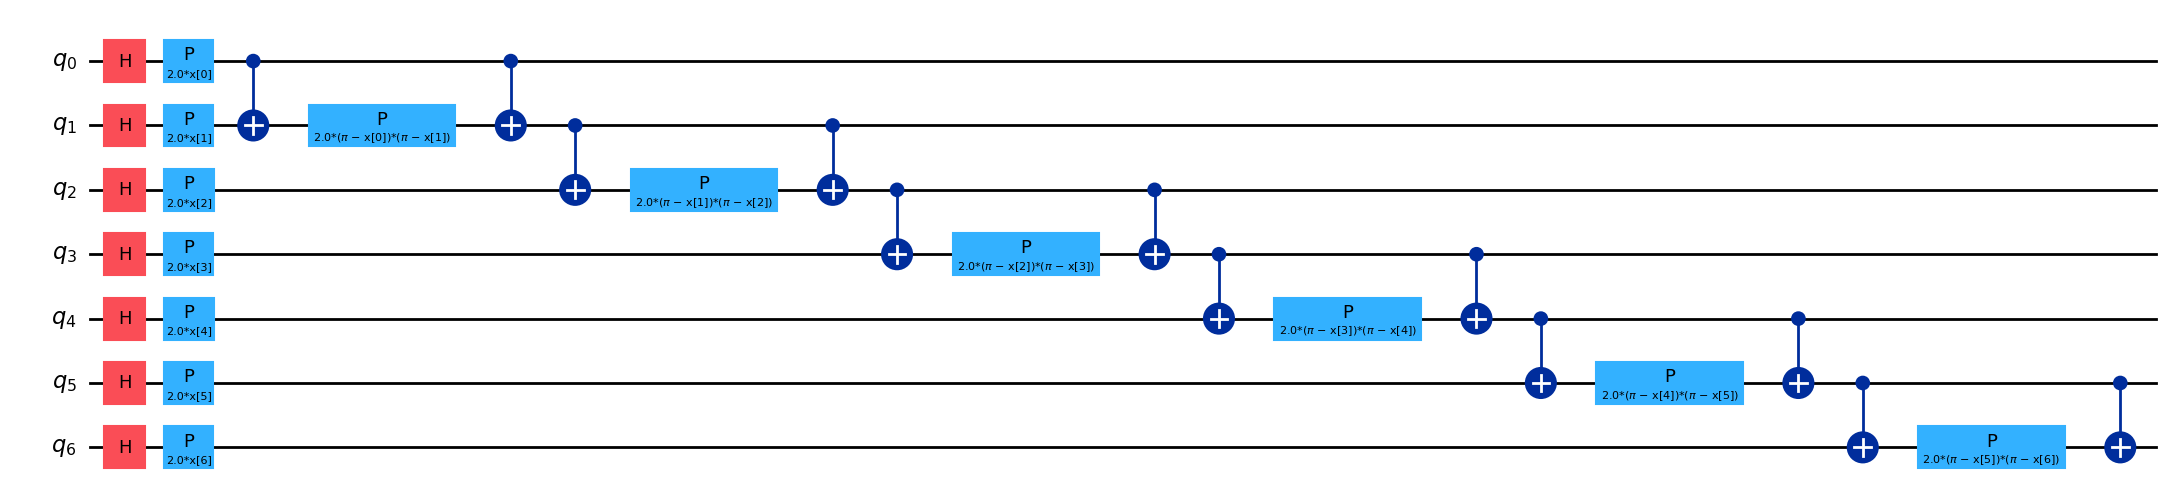


=== ZZ_full ===


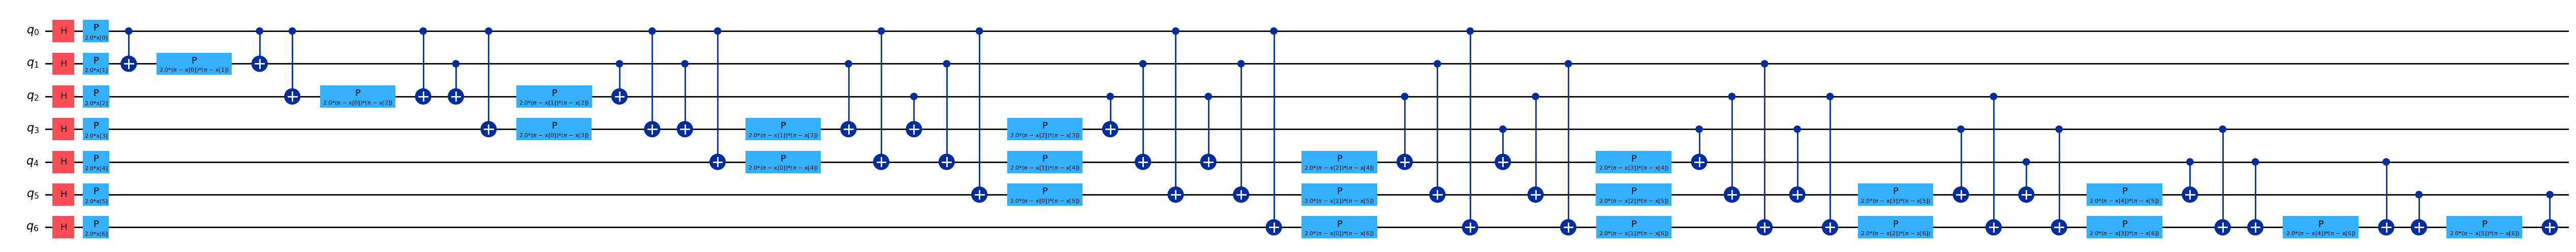

In [14]:
# Begin Quantum implementation
## Section 3 — Build the quantum feature maps 
# A feature map is a circuit `U(x)` that encodes
#  a classical point `x` into a quantum state
#  `|φ(x)⟩ = U(x)|0⟩`. The quantum kernel is then
#  `K(x_i, x_j) = |⟨φ(x_i)|φ(x_j)⟩|²`. We build 
# two `ZZFeatureMap`s (7 qubits, `reps=1`), 
# differing only in entanglement: - **linear**
#  — entangles adjacent qubit pairs only → 
# shallower, less noise on hardware. - **full** — 
# entangles all qubit pairs → more expressive, 
# but deeper/noisier.

n_qubits = X_train.shape[1]  # 7 features → 7 qubits

zz_linear_featuremap = ZZFeatureMap(feature_dimension=n_qubits, reps=1, entanglement="linear")

zz_full_featuremap = ZZFeatureMap(feature_dimension=n_qubits, reps=1, entanglement="full")

featuremaps = {"ZZ_linear": zz_linear_featuremap, "ZZ_full": zz_full_featuremap}

for name, fm in featuremaps.items():
    decomposed = fm.decompose()
    print(f"{name:10s} | depth: {decomposed.depth():3d} | "
          f"gates: {dict(decomposed.count_ops())}")

# Visualize both feature maps (decomposed into elementary gates)
for name, fm in featuremaps.items():
    print(f"\n=== {name} ===")
    display(fm.decompose().draw("mpl", fold=-1))

In [15]:
## Section 4 — QSVM on the simulator (full data)

#Wrap each feature map in a `FidelityStatevectorKernel` — an **exact, noiseless** kernel
#computed on CPU. It simulates `|φ(x)⟩` for each of the 711 training points once, then takes
#inner products, so the full kernel matrix is cheap. `QSVC` is just an `SVC` that uses this
#quantum kernel. These are the *real* quantum-vs-classical accuracy numbers.

for name , fm in featuremaps.items():
    kernel = FidelityStatevectorKernel(feature_map=fm)
    qsvc = QSVC(quantum_kernel=kernel)
    t0 = time()
    qsvc.fit(X_train, y_train)
    accuracy_sim_qsvc = accuracy_score(y_test, qsvc.predict(X_test))
    results[f"QSVC {name}"] = accuracy_sim_qsvc
    print(f"QSVC with {name} feature map accuracy: {accuracy_sim_qsvc:.4f} (fit + predict time: {time() - t0:.1f}s)")

QSVC with ZZ_linear feature map accuracy: 0.8090 (fit + predict time: 2.0s)
QSVC with ZZ_full feature map accuracy: 0.8315 (fit + predict time: 2.7s)


In [16]:
X_train_s, _, y_train_s, _ = train_test_split(
    X_train, y_train, train_size=16, stratify=y_train, random_state=RANDOM_STATE
)
X_test_s, _, y_test_s, _ = train_test_split(
    X_test, y_test, train_size=8, stratify=y_test, random_state=RANDOM_STATE
)

print(f"subsample train: {X_train_s.shape}  class balance {np.bincount(y_train_s)}")
print(f"subsample test:  {X_test_s.shape}  class balance {np.bincount(y_test_s)}")

# Rough circuit budget for the hardware run (per feature map):
n_train_pairs = 16 * 15 // 2       # symmetric train kernel, off-diagonal
n_test_pairs  = 8 * 16             # test-vs-train kernel
print(f"\n~{n_train_pairs + n_test_pairs} kernel circuits per feature map "
      f"({n_train_pairs} train + {n_test_pairs} test)")


subsample train: (16, 7)  class balance [10  6]
subsample test:  (8, 7)  class balance [5 3]

~248 kernel circuits per feature map (120 train + 128 test)


In [17]:
# checking the small data sample in simulator

for name, fm in featuremaps.items():
    kernel = FidelityStatevectorKernel(feature_map=fm)
    qsvc = QSVC(quantum_kernel=kernel)
    qsvc.fit(X_train_s, y_train_s)
    acc = accuracy_score(y_test_s, qsvc.predict(X_test_s))
    results[f"QSVC sim-sub {name}"] = acc
    print(f"QSVC sim (subsample) {name:9s}: {acc:.4f}")


QSVC sim (subsample) ZZ_linear: 0.6250
QSVC sim (subsample) ZZ_full  : 0.6250


In [18]:
algorithm_globals.random_seed = RANDOM_STATE      # reproducible sampling
load_dotenv()                                      # reads QSVM/.env
token = os.environ["IBM_QUANTUM_TOKEN"]

service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token)

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_qubits)
print("Backend:", backend.name, "|", backend.num_qubits, "qubits")

# ComputeUncompute uses this to transpile the fidelity circuits to the device's native gates.
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

qiskit_runtime_service._resolve_cloud_instances:WARNING:2026-06-01 21:55:59,517: Default instance not set. Searching all available instances.


Backend: ibm_fez | 156 qubits


In [19]:
# === Helper functions for the hardware quantum kernel ===
# We compute the kernel by hand with PARAMETER-FREE circuits. The built-in parametric
# FidelityQuantumKernel path hits a QPY (ParameterVector) serialization bug on the IBM
# cloud, so we bind the data values *before* transpiling instead.
from qiskit import QuantumCircuit


def fidelity_circuit(fm, a, b):
    """One circuit for the kernel value K(a, b) = |<phi(b)|phi(a)>|^2.
    Run U(a), then U(b)-dagger; if a and b are similar we land back near |0...0>.
    Values are bound BEFORE transpilation, so no ParameterVector is sent to the cloud."""
    qc = QuantumCircuit(fm.num_qubits)
    qc.compose(fm.assign_parameters(a), inplace=True)            # U(a):  |0> -> |phi(a)>
    qc.compose(fm.assign_parameters(b).inverse(), inplace=True)  # U(b)†: undo towards |0>
    qc.measure_all()
    return qc


def quantum_kernel_matrix(fm, A, B, sampler, pm):
    """Kernel matrix K[i, j] = |<phi(B[j])|phi(A[i])>|^2.
    B=None -> symmetric (training) matrix. Each pair's circuit is transpiled by `pm`
    and executed on `sampler`. The fidelity is the probability of measuring all zeros."""
    zero = "0" * fm.num_qubits
    symmetric = B is None
    if symmetric:
        B = A
    circuits, pairs = [], []
    for i in range(len(A)):
        for j in (range(i, len(B)) if symmetric else range(len(B))):
            circuits.append(pm.run(fidelity_circuit(fm, A[i], B[j])))
            pairs.append((i, j))
    result = sampler.run(circuits).result()
    K = np.zeros((len(A), len(B)))
    for (i, j), r in zip(pairs, result):
        counts = r.data.meas.get_counts()
        fid = counts.get(zero, 0) / sum(counts.values())   # fidelity = P(all zeros)
        K[i, j] = fid
        if symmetric:
            K[j, i] = fid
    return K


def make_psd(K, eps=1e-8):
    """Clip negative eigenvalues so a noisy Gram matrix is valid for SVC(kernel='precomputed').
    Replaces FidelityQuantumKernel's enforce_psd, which we no longer use."""
    vals, vecs = np.linalg.eigh((K + K.T) / 2)
    return (vecs * np.clip(vals, eps, None)) @ vecs.T

In [20]:
# === DRY RUN: validate the hardware pipeline locally on a FAKE backend (no queue, no quota) ===
# FakeSherbrooke is a local noisy simulator that mimics a real device (ISA + noise), so this
# exercises the EXACT same path as the hardware cell (helpers + pass_manager + SamplerV2),
# just for free. If this gives sensible accuracies, the hardware cell is safe to run.
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

fake_backend = FakeSherbrooke()
pm_dry = generate_preset_pass_manager(optimization_level=1, backend=fake_backend)
sampler_dry = SamplerV2(mode=fake_backend, options={"default_shots": SHOTS})

K_matrix_train_dry, K_matrix_test_dry, results_dry = {}, {}, {}

for name, fm in featuremaps.items():
    print(f"\nRunning dry-run kernel for {name} feature map...")
    t0 = time()
    K_tr = quantum_kernel_matrix(fm, X_train_s, None,      sampler_dry, pm_dry)   # 16x16
    K_te = quantum_kernel_matrix(fm, X_test_s,  X_train_s, sampler_dry, pm_dry)   # 8x16

    svc = SVC(kernel="precomputed")
    svc.fit(make_psd(K_tr), y_train_s)
    acc = accuracy_score(y_test_s, svc.predict(K_te))

    K_matrix_train_dry[name], K_matrix_test_dry[name] = K_tr, K_te
    results_dry[f"QSVC dry {name}"] = acc
    print(f"[dry-run] {name:9s}: acc={acc:.4f}   ({time() - t0:.0f}s)")


Running dry-run kernel for ZZ_linear feature map...
[dry-run] ZZ_linear: acc=0.6250   (10s)

Running dry-run kernel for ZZ_full feature map...
[dry-run] ZZ_full  : acc=0.6250   (33s)


In [ ]:
# === REAL IBM HARDWARE RUN ===  Uses the IBM queue + your QPU quota.
# Guarded so "Run All" does NOT submit. Set this to True and re-run ONLY this cell to go live.
RUN_HARDWARE = False

if not RUN_HARDWARE:
    print("Skipped hardware run (RUN_HARDWARE=False). Set it True and re-run this cell to submit to IBM.")
else:
    # Same helpers/path validated by the dry-run above, but on the real `backend` + `pm`.
    K_matrix_train_hw, K_matrix_test_hw = {}, {}

    with Batch(backend=backend) as batch:
        sampler = SamplerV2(mode=batch, options={"default_shots": SHOTS})

        for name, fm in featuremaps.items():
            print(f"\nRunning hardware kernel for {name} feature map...")
            t0 = time()
            K_tr = quantum_kernel_matrix(fm, X_train_s, None,      sampler, pm)   # 16x16
            K_te = quantum_kernel_matrix(fm, X_test_s,  X_train_s, sampler, pm)   # 8x16

            svc = SVC(kernel="precomputed")
            svc.fit(make_psd(K_tr), y_train_s)
            acc = accuracy_score(y_test_s, svc.predict(K_te))

            K_matrix_train_hw[name] = K_tr      # store RAW matrices for the noise heatmap
            K_matrix_test_hw[name] = K_te
            results[f"QSVC hw-sub {name}"] = acc
            print(f"[hardware] {name:9s}: acc={acc:.4f}   ({time() - t0:.0f}s)")


Running hardware kernel for ZZ_linear feature map...
[hardware] ZZ_linear: acc=0.6250   (325s)

Running hardware kernel for ZZ_full feature map...


RuntimeInvalidStateError: 'Unable to retrieve result for job d8er9ijalsvc7390omhg. Job was cancelled.'

In [23]:
print("train keys:", list(K_matrix_train_hw.keys()))
print("test  keys:", list(K_matrix_test_hw.keys()))
print("shapes:", {k: v.shape for k, v in K_matrix_train_hw.items()})
print("hw acc:", {k: v for k, v in results.items() if "hw-sub" in k})


train keys: ['ZZ_linear']
test  keys: ['ZZ_linear']
shapes: {'ZZ_linear': (16, 16)}
hw acc: {'QSVC hw-sub ZZ_linear': 0.625}


In [24]:
# verify it's there, then save
print(K_matrix_train_hw.keys(), K_matrix_train_hw["ZZ_linear"].shape)

np.savez("hw_kernel_ZZ_linear.npz",
         K_train=K_matrix_train_hw["ZZ_linear"],
         K_test=K_matrix_test_hw["ZZ_linear"])
print("saved hw_kernel_ZZ_linear.npz")


dict_keys(['ZZ_linear']) (16, 16)
saved hw_kernel_ZZ_linear.npz
